# 1 Introduction mnist

## A simple classifier for mnist digits

mnist is a standard data set of hand-written digits widely used in machine learning.


We will explore the data set and write a simple classifier.


We will define a template for each digit and predict a label for an unseen image by judging to which of the 10 digit templates the image is the most similar.





### Load mnist data

In [2]:
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from tqdm import tqdm



# load mnist data separated into images (x) and labels (y)
# and separated into training and test data

(x_train, y_train), (x_test, y_test) = mnist.load_data()


# label2id is a dictionary with digit as key and
# a list of ids for that digits

label2id = defaultdict(list)
for i,y in enumerate(y_train):
  label2id[y].append(i)



ModuleNotFoundError: No module named 'keras'

In [ ]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_train[1]:", x_train[1].shape)

x_train: (60000, 28, 28)
y_train: (60000,)
x_train[1]: (28, 28)


### Function to show image, actual label, predicted label

In [88]:
# show takes a list of images and list of labels and
# plots them next to each other
# optionally predicted labels y_pred can be defined

def show(x,y, y_pred=None):
  n = len(x)
  plt.figure(figsize=(n, 1))        # plot n digits next to each other
  for i in range(n):
    plt.subplot(1, n, i+1)
    plt.axis('off')
    plt.imshow(x[i].reshape(28,28), cmap='gray', vmin=0, vmax=255)

    if y_pred is not None:          # print true and poredicted label
      plt.title("%d/%d"%(y[i],y_pred[i]))
    elif len(y) > 0:
      plt.title("%d"%y[i])
  plt.show()



(28, 28)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0  67 232  39   0   0   0   0   0]
 [  0   0   0   0  62  81   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 120 180  39   0   0   0   0   0]
 [  0   0   0   0 126 163   0   0   0   0   0   0   0   0   0   0   0   0
    0   2 153 210  40   0   0   0   0   0]
 [  0   0   0   0 220 163   0   0   0   0   0   0   0  

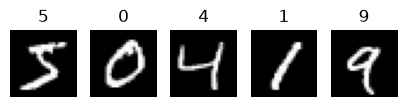

In [89]:
#
#So basically, there are 60,000 training images and 10,000 test image. 
# Each IMAGE is 28*28 pixels (2D) 
#       --> NumPy Array with 28 rows with 28 columns, 
#           and can be considered as a matrix with 
#           28 rows and 28 columns with values from 0-255 each.

#Can be flattened to 1D array of 784 pixels (784 values from 0-255)
print(x_train[2].shape)
print(x_train[2])
#input parameters 
# x: actual images
# y: actual labels(can be more than x, 
#                  will simply be ignored because 
#                  the loop does not run more than 
#                  n times(length of x))
#y_pred: predicted labels(optional: they are just the label PREDICTED
#                          by the model, but i am not using a model yet, 
#                          so i just give them manually (or not))
#

show(x_train[:5], y_train[:5])

### Show a random example from mnist

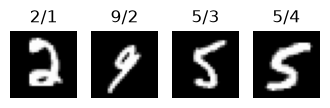

In [90]:
def random_xy():
    i = np.random.randint(0, len(x_train))
    
    return (x_train[i],y_train[i])

def random_xys(n):
    xs,ys = [],[]

    for _ in range(n):
        x,y = random_xy()
        xs.append(x)
        ys.append(y)

    return (xs,ys)

#
# Here, * is used to unpack the list of images and labels
# returned by random_xys(4) into separate arguments for the show function.
#
show(*random_xys(4),[1,2,3,4])

### How to represent the images?

Gray scale from 0 (black) to 255 (white) or just black and white? Where to set a threshold to convert gray scale to b/w?

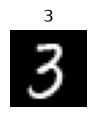

[array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14, 142, 158, 158,
        237, 254, 255, 255, 163,   6,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [ 

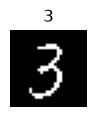

[array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        255, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [ 

In [120]:
xs,ys = random_xys(1)
#xs,ys= x_train[5:6], y_train[5:6]
show(xs,ys)
print(xs)

threshold = 200 #@param {type:"number"}
binary = True #@param {type:"boolean"}

#
#It checks each pixel, compares the threshold, 
#and if it is greater than threshold, it will set the pixel to 255 (white) --> binary true
#else it will leave it as is. If the pixel is less than or
# equal to threshold, it will set the pixel to 0 (black).
#
def bw(img, threshold):
  for i in range(28):
    for j in range(28):
      if img[i,j]>threshold:
        if binary: img[i,j]=255 # if threshold > 255, this will not make a difference
                                # the code does not get to this point, 
                                # it just skips the whole block in the previous step, 
                                # and makes all pixels 0(black)
      else:
        img[i,j]=0
  return img

for i in range(len(xs)):
  xs[i]=bw(xs[i], threshold)

show(xs,ys)
print(xs)
print(xs[0].max(), xs[0].min())

### Select template. Pick first or pick randomly

In [1]:
# return a tutple with lists of 10 images and their labels,
# which will serve as templates for the digits

random = False #@param{type:"boolean"}

def select_templates(random=True):

  x_template = []
  y_template = []

  for label,ids in sorted(label2id.items()):
    if random:
      i = np.random.randint(0, len(label2id[label]))
      x_template.append(x_train[ids[i]])
    else:
      x_template.append(x_train[ids[0]])
    y_template.append(label)

  return x_template, y_template

# Show the selected template images

x_template, y_template = select_templates(random=random)
#print(x_template, y_template)
show(x_template, y_template)


NameError: name 'label2id' is not defined

### Define Distance

Euclidean distance 2639.2783104477635
Intersection on binary representation 774


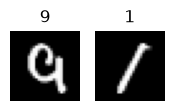

In [127]:
# define the distance between two images
# as the pixel-wise euclidean distance
#
# Proceed by turning the images, which are arrays of numbers, into vectors with flatten
# and then compute the distance using numpy.linalg.norm to compute Euclidean distance

def dist(img1,img2):
  v1 = img1.flatten()
  v2 = img2.flatten()
  return np.linalg.norm(v1-v2)

def cosine_similarity(img1, img2):
    v1 = img1.flatten()
    v2 = img2.flatten()
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))


def dist_binary_intersection(img1,img2):
  v1 = img1.flatten()
  v2 = img2.flatten()
  # range is 0 = black, 255 white. Most pixels are 0

  count = np.dot((v1 >= threshold).astype(int), (v2 >= threshold).astype(int))
  #count_slow = sum([1 for i1,i2 in zip(v1,v2) if i1>=threshold and i2>=threshold])

  # 784 minus sum to make small value best
  return 784-count

# Pick two random images and calculate their distance and show them

x1,y1 = random_xy()
x2,y2 = random_xy()
print(f"Euclidean distance {dist(x1,x2)}")
print(f"Intersection on binary representation {dist_binary_intersection(x1,x2)}")
show([x1,x2],[y1,y2])
